In [1]:
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr
import cartopy.feature as cfeature


from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import LeaveOneOut

In [2]:
# oni
oni_ersst = xr.open_dataset('data/oni.nc')

oni_series = oni_ersst['value'].to_series()
oni_series

# roni 
roni_ersst = xr.open_dataset('data/roni.nc')

roni_series = roni_ersst['value'].to_series()
roni_series

time
1949-01-01     NaN
1949-02-01     NaN
1949-03-01     NaN
1949-04-01     NaN
1949-05-01     NaN
              ... 
2026-04-01   -0.13
2026-05-01    0.52
2026-06-01    1.07
2026-07-01    1.33
2026-08-01    1.67
Name: value, Length: 932, dtype: float32

In [3]:
# HadISST oni and roni calculation 

hadisst = xr.open_dataset('data/HadISST_sst.nc')
hadisst
# print(hadsst['sst'].compute())


<xarray.Dataset> Size: 487MB
Dimensions:    (time: 1879, nv: 2, latitude: 180, longitude: 360)
Coordinates:
  * time       (time) datetime64[ns] 15kB 1870-01-16T11:59:59.505615234 ... 2...
  * latitude   (latitude) float32 720B 89.5 88.5 87.5 86.5 ... -87.5 -88.5 -89.5
  * longitude  (longitude) float32 1kB -179.5 -178.5 -177.5 ... 178.5 179.5
Dimensions without coordinates: nv
Data variables:
    time_bnds  (time, nv) float32 15kB ...
    sst        (time, latitude, longitude) float32 487MB ...
Attributes:
    Title:                      Monthly version of HadISST sea surface temper...
    description:                HadISST 1.1 monthly average sea surface tempe...
    institution:                Met Office Hadley Centre
    source:                     HadISST
    reference:                  Rayner, N. A., Parker, D. E., Horton, E. B., ...
    Conventions:                CF-1.0
    history:                    3/9/2026 converted to netcdf from pp format
    supplementary_information:  Updates and supplementary information will be...
    comment:                    Data restrictions: for academic research use ...

In [4]:
# Niño 3.4 region (5°N–5°S, 120–170°W)

nino34 = hadisst['sst'].sel(
    latitude=slice(5, -5),
    longitude=slice(-170, -120)
)
# print (nino34)

nino34_sst = nino34.mean(
    dim=['latitude', 'longitude'],
    skipna=True
)
# print (nino34_sst)

clim = (
    nino34_sst
    .sel(time=slice('1991-01', '2020-12'))
    .groupby('time.month')
    .mean('time')
)

nino34_anom = nino34_sst.groupby('time.month') - clim

# print (nino34_anom)

oni = nino34_anom.rolling(time=3, center=True).mean()
oni

<xarray.DataArray 'sst' (time: 1879)> Size: 8kB
array([       nan, -1.0212358, -0.989179 , ...,  0.7424838,  1.2523651,
              nan], dtype=float32)
Coordinates:
  * time     (time) datetime64[ns] 15kB 1870-01-16T11:59:59.505615234 ... 202...
    month    (time) int64 15kB 1 2 3 4 5 6 7 8 9 10 ... 10 11 12 1 2 3 4 5 6 7

In [5]:
# calculate tropical sst climatology 
tropical = hadisst['sst'].sel(
    latitude=slice(20, -20)
)

tropical_sst = tropical.mean( # spatial mean of entire tropical -> single time series 
    dim=['latitude', 'longitude'],
    skipna = True
)

tropical_clim = ( # base climatology of entire tropical SST 1991-2020
    tropical_sst
    .sel(time=slice('1991-01', '2020-12'))
    .groupby('time.month')
    .mean('time')
)

tropical_anom = ( # anomaly of entire tropcial SST 
    tropical_sst.groupby('time.month')
    - tropical_clim
)





In [6]:
# Oldenborgh et al. (2021) scaling factor:  
# We therefore propose to renormalize the series to the same variability as the original Niño3.4 series by 
# multiplying by 1/(1 − A) with A the regression of the 20◦ S–20◦ N SST anomalies on the Niño3.4 index after 
# taking year-on-year differences to isolate the ENSO signal. The regression has a strong seasonal cycle, 
# so it is determined for each month separately (averaging over the two adjoining months in the fit to increase 
# the signal/noise ratio).” ([Oldenborgh et al., 2021, p. 5]

# year-on-year differences 
nino34_yoy = nino34_anom - nino34_anom.shift(time=12)
tropical_yoy = tropical_anom - tropical_anom.shift(time=12)

# month-specific regression coefficients  A
A = {}

for month in range (1,13):
    # month + adjoining months
    if month == 1:
        months = [12,1,2]
    elif month == 12:
        months = [11,12,1]
    else: months = [month -1, month, month +1]

    nino_subset = nino34_yoy.where(
        nino34_yoy['time.month'].isin(months),
        drop = True
    )

    tropical_subset = tropical_yoy.where(
        tropical_yoy['time.month'].isin(months),
        drop = True
    ) 

    # Regression: tropical_yoy = A * nino34_yoy 
    # calcuate regression coeffcient that fits entire data
    A[month] = (
        (nino_subset * tropical_subset).sum() 
        / (nino_subset ** 2).sum()
    ) 


In [7]:
nino_subset
tropical_subset.shape
A[1]
nino34_yoy

<xarray.DataArray 'sst' (time: 1879)> Size: 8kB
array([      nan,       nan,       nan, ..., 0.8760624, 1.3653831,
       1.9419804], dtype=float32)
Coordinates:
  * time     (time) datetime64[ns] 15kB 1870-01-16T11:59:59.505615234 ... 202...
    month    (time) int64 15kB 1 2 3 4 5 6 7 8 9 10 ... 10 11 12 1 2 3 4 5 6 7

In [8]:
A = xr.DataArray(
    [A[month] for month in range (1,13)],
    dims = 'month',
    coords = {'month': range (1,13)}
)

In [9]:
# Finally RONI
roni_relative= nino34_anom - tropical_anom # not scaled

# rescale to match variance 
roni_monthly = (
    roni_relative.groupby('time.month')
    / (1 - A) 
)

roni_monthly

# 3 month running mean
roni = roni_monthly.rolling(time=3, center=True).mean()
roni 

<xarray.DataArray (time: 1879)> Size: 8kB
array([        nan, -0.61282694, -0.50545096, ...,  0.48597842,
        0.97632456,         nan], dtype=float32)
Coordinates:
  * time     (time) datetime64[ns] 15kB 1870-01-16T11:59:59.505615234 ... 202...
    month    (time) int64 15kB 1 2 3 4 5 6 7 8 9 10 ... 10 11 12 1 2 3 4 5 6 7

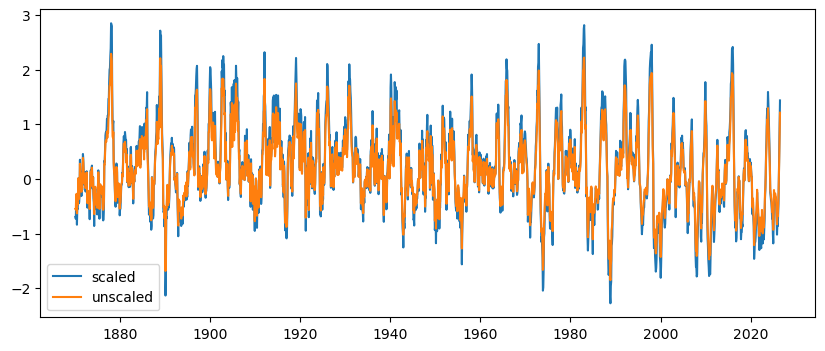

In [10]:
plt.figure(figsize=(10, 4))
plt.plot(roni_monthly['time'], roni_monthly, label = 'scaled')
plt.plot(roni_relative['time'], roni_relative, label = 'unscaled')
plt.legend()

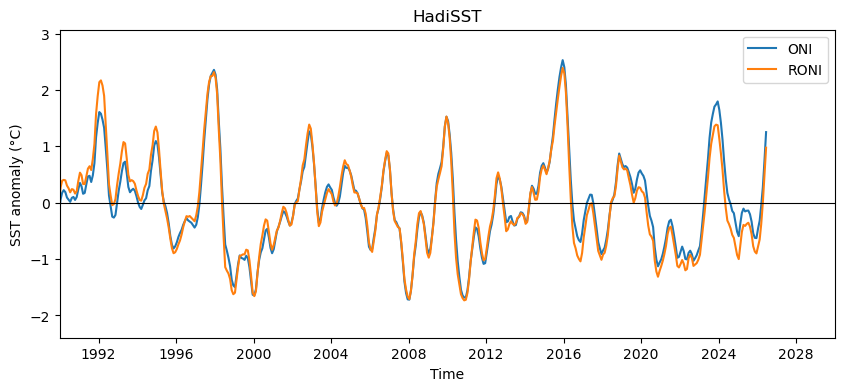

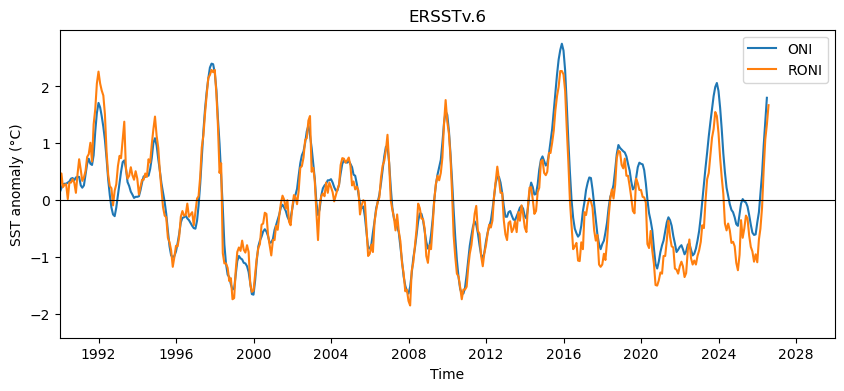

In [11]:
plt.figure(figsize=(10, 4))
plt.plot(oni['time'], oni, label='ONI')
plt.plot(roni['time'], roni, label='RONI')
plt.xlim(pd.to_datetime("1990"), pd.to_datetime("2030"))


plt.axhline(0, color='black', linewidth=0.8)
plt.legend()
plt.xlabel('Time')
plt.ylabel('SST anomaly (°C)')
plt.title('HadiSST')
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(oni_ersst['time'], oni_series, label='ONI')
plt.plot(roni_ersst['time'], roni_series, label='RONI')
plt.xlim(pd.to_datetime("1990"), pd.to_datetime("2030"))

plt.axhline(0, color='black', linewidth=0.8)
plt.legend()
plt.xlabel('Time')
plt.ylabel('SST anomaly (°C)')
plt.title('ERSSTv.6')
plt.show()

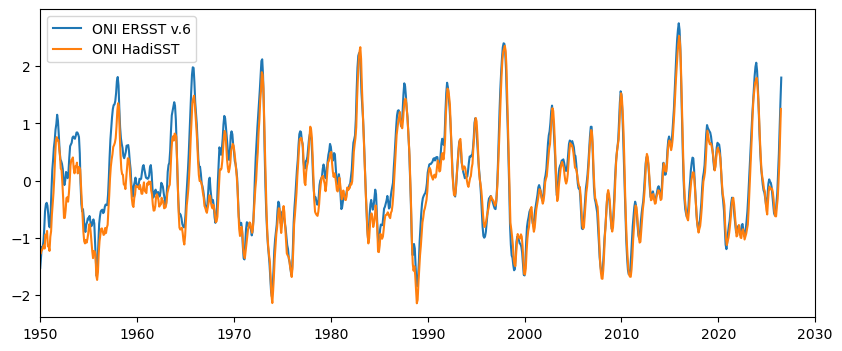

In [12]:
plt.figure(figsize=(10, 4))
plt.plot(oni_ersst['time'], oni_series, label='ONI ERSST v.6')
plt.plot(oni['time'], oni, label='ONI HadiSST')
plt.xlim(pd.to_datetime("1950"), pd.to_datetime("2030"))
plt.legend()


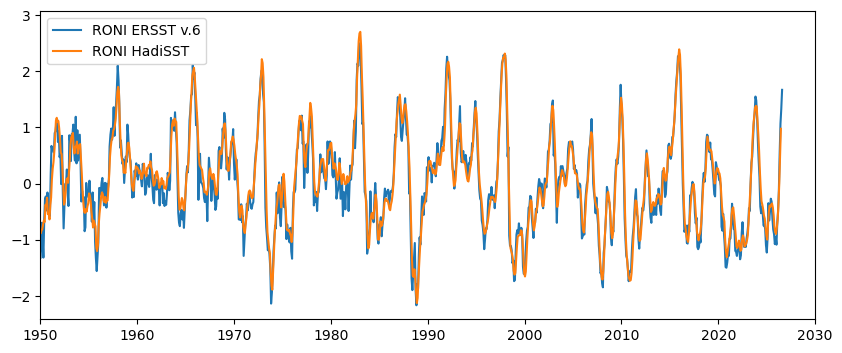

In [17]:
plt.figure(figsize=(10, 4))
plt.plot(roni_ersst['time'], roni_series, label='RONI ERSST v.6')
plt.plot(roni['time'], roni, label='RONI HadiSST')
plt.xlim(pd.to_datetime("1950"), pd.to_datetime("2030"))
plt.legend()

In [13]:
# why does HadiSST look like they have less divergence towards recent decades? -> seems to have slightly different SST vals compared to ERSSTv.6 data
# from looking at only ONI from both dataset - oni is just nino3.4 3 month averaged, nino 3.4 is monthly SST - clim
# fixed after rescaling but pre 1990 still diverges alot compared to ERSSTv.6
# looking from 1990 onwards, RONI and ONI starts to diverge from 2013? 

In [14]:
roni

<xarray.DataArray (time: 1879)> Size: 8kB
array([        nan, -0.61282694, -0.50545096, ...,  0.48597842,
        0.97632456,         nan], dtype=float32)
Coordinates:
  * time     (time) datetime64[ns] 15kB 1870-01-16T11:59:59.505615234 ... 202...
    month    (time) int64 15kB 1 2 3 4 5 6 7 8 9 10 ... 10 11 12 1 2 3 4 5 6 7

In [15]:
oni.to_netcdf('data/oni_hadisst.nc')

In [16]:
roni.rename('sst').to_netcdf('data/roni_hadisst.nc')